# EDA: Spatiotemporal Analysis of Crash Demand Patterns

**EMS Readiness Optimization Project - Phase 1**

This notebook analyzes crash demand patterns in Manhattan to inform the discrete-event simulation of EMS staging. Understanding when and where crashes occur is crucial for:

1. **Demand Modeling**: Identifying temporal patterns (hourly, daily, seasonal) for stochastic arrival processes
2. **Spatial Allocation**: Understanding geographic distribution for optimal ambulance positioning
3. **CBD Analysis**: Comparing high-density CBD vs rest of Manhattan for robustness testing

---

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Project root: /home/ubuntu/ems-optimization
Figures will be saved to: /home/ubuntu/ems-optimization/results/figures


In [2]:
# Load crashes data
crashes = pd.read_parquet(DATA_DIR / 'processed' / 'crashes_manhattan.parquet')

# Parse datetime columns
crashes['crash_datetime'] = pd.to_datetime(crashes['crash_datetime'])
crashes['date'] = crashes['crash_datetime'].dt.date
crashes['hour'] = crashes['crash_datetime'].dt.hour
crashes['day_of_week'] = crashes['crash_datetime'].dt.dayofweek  # 0=Monday
crashes['day_name'] = crashes['crash_datetime'].dt.day_name()
crashes['month'] = crashes['crash_datetime'].dt.month
crashes['year'] = crashes['crash_datetime'].dt.year
crashes['month_name'] = crashes['crash_datetime'].dt.month_name()

print(f"Loaded {len(crashes):,} crash records")
print(f"Date range: {crashes['crash_datetime'].min()} to {crashes['crash_datetime'].max()}")

Loaded 416,434 crash records
Date range: 2012-07-01 00:05:00 to 2026-02-20 23:51:00


In [3]:
# Load firehouses
firehouses = pd.read_csv(DATA_DIR / 'processed' / 'firehouses_clean.csv')
firehouses_manhattan = firehouses[firehouses['in_manhattan'] == True].copy()

print(f"Total firehouses: {len(firehouses)}")
print(f"Manhattan firehouses: {len(firehouses_manhattan)}")
print(f"CBD firehouses: {firehouses['in_cbd'].sum()}")

Total firehouses: 219
Manhattan firehouses: 48
CBD firehouses: 27


In [4]:
# Load geographic boundaries
precincts = gpd.read_file(DATA_DIR / 'processed' / 'precincts_manhattan.geojson')
manhattan_boundary = gpd.read_file(DATA_DIR / 'raw' / 'manhattan_boundary.geojson')
cbd_boundary = gpd.read_file(DATA_DIR / 'raw' / 'cbd_boundary.geojson')

print(f"Manhattan precincts: {len(precincts)}")

Manhattan precincts: 30


---

## Key Statistics Summary

Overview of the crash dataset relevant to EMS simulation design.

In [5]:
# Calculate key statistics
total_crashes = len(crashes)
date_range_days = (crashes['crash_datetime'].max() - crashes['crash_datetime'].min()).days
date_range_years = date_range_days / 365.25

# Daily and hourly averages
crashes_per_day = total_crashes / date_range_days
crashes_per_hour = crashes_per_day / 24

# CBD statistics
cbd_crashes = crashes['in_cbd'].sum()
cbd_proportion = cbd_crashes / total_crashes * 100

# Peak identification
hourly_counts = crashes.groupby('hour').size()
peak_hour = hourly_counts.idxmax()
peak_hour_count = hourly_counts.max()

daily_counts = crashes.groupby('day_name').size()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_counts = daily_counts.reindex(day_order)
peak_day = daily_counts.idxmax()

print("="*60)
print("KEY STATISTICS - Manhattan Crash Demand")
print("="*60)
print(f"\n DATASET OVERVIEW")
print(f"   Total crashes: {total_crashes:,}")
print(f"   Date range: {crashes['crash_datetime'].min().strftime('%Y-%m-%d')} to {crashes['crash_datetime'].max().strftime('%Y-%m-%d')}")
print(f"   Duration: {date_range_days:,} days ({date_range_years:.1f} years)")
print(f"\n DEMAND RATES")
print(f"   Average crashes per day: {crashes_per_day:.1f}")
print(f"   Average crashes per hour: {crashes_per_hour:.2f}")
print(f"   Peak hour: {peak_hour}:00 ({peak_hour_count:,} total crashes)")
print(f"   Peak day: {peak_day}")
print(f"\n CBD ANALYSIS")
print(f"   CBD crashes: {cbd_crashes:,} ({cbd_proportion:.1f}% of total)")
print(f"   Non-CBD crashes: {total_crashes - cbd_crashes:,} ({100-cbd_proportion:.1f}% of total)")
print("="*60)

KEY STATISTICS - Manhattan Crash Demand

 DATASET OVERVIEW
   Total crashes: 416,434
   Date range: 2012-07-01 to 2026-02-20
   Duration: 4,982 days (13.6 years)

 DEMAND RATES
   Average crashes per day: 83.6
   Average crashes per hour: 3.48
   Peak hour: 16:00 (28,356 total crashes)
   Peak day: Friday

 CBD ANALYSIS
   CBD crashes: 231,786 (55.7% of total)
   Non-CBD crashes: 184,648 (44.3% of total)


---

## 1. Temporal Analysis

Understanding temporal patterns is essential for simulation design:
- **Hourly patterns** inform time-varying arrival rates
- **Daily patterns** help identify weekday vs weekend differences
- **Seasonal patterns** reveal long-term trends

### 1.1 Hourly Distribution of Crashes

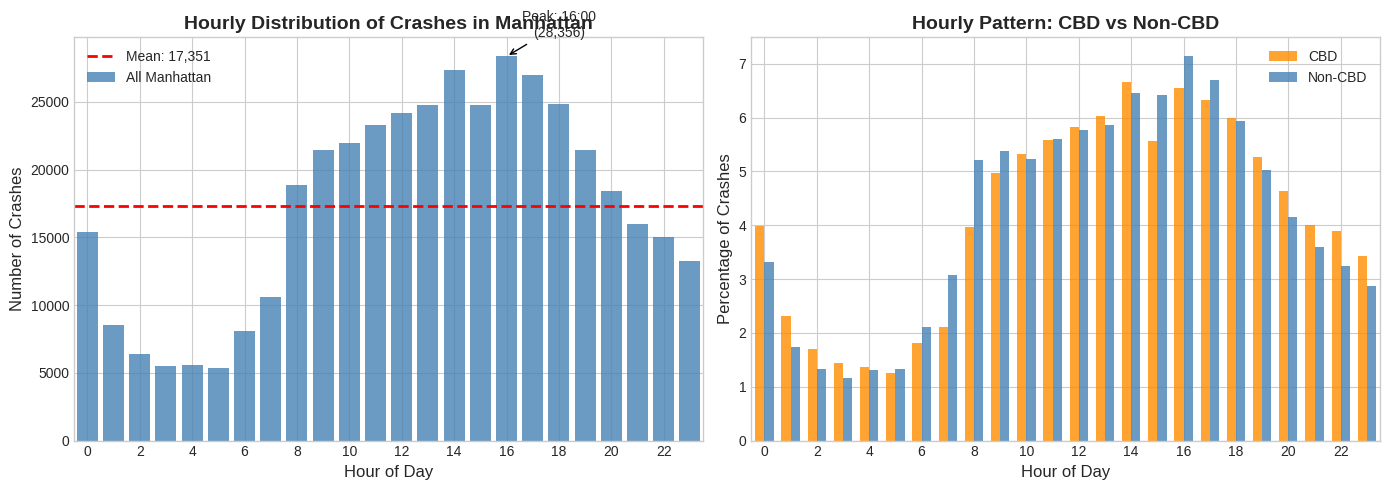


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_hourly_demand.png


In [6]:
# Hourly distribution - overall and by CBD
hourly_all = crashes.groupby('hour').size()
hourly_cbd = crashes[crashes['in_cbd']].groupby('hour').size()
hourly_non_cbd = crashes[~crashes['in_cbd']].groupby('hour').size()

# Calculate proportions
hourly_pct = hourly_all / hourly_all.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Absolute counts
ax1 = axes[0]
hours = range(24)
ax1.bar(hours, hourly_all.values, color='steelblue', alpha=0.8, label='All Manhattan')
ax1.axhline(hourly_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {hourly_all.mean():,.0f}')
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('Number of Crashes', fontsize=12)
ax1.set_title('Hourly Distribution of Crashes in Manhattan', fontsize=14, fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.legend()
ax1.set_xlim(-0.5, 23.5)

# Annotate peak
peak_hr = hourly_all.idxmax()
ax1.annotate(f'Peak: {peak_hr}:00\n({hourly_all.max():,})', 
             xy=(peak_hr, hourly_all.max()), 
             xytext=(peak_hr+2, hourly_all.max()*1.05),
             fontsize=10, ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

# Right: CBD vs Non-CBD comparison
ax2 = axes[1]
width = 0.35
x = np.arange(24)
ax2.bar(x - width/2, hourly_cbd.values / hourly_cbd.sum() * 100, width, label='CBD', color='darkorange', alpha=0.8)
ax2.bar(x + width/2, hourly_non_cbd.values / hourly_non_cbd.sum() * 100, width, label='Non-CBD', color='steelblue', alpha=0.8)
ax2.set_xlabel('Hour of Day', fontsize=12)
ax2.set_ylabel('Percentage of Crashes', fontsize=12)
ax2.set_title('Hourly Pattern: CBD vs Non-CBD', fontsize=14, fontweight='bold')
ax2.set_xticks(range(0, 24, 2))
ax2.legend()
ax2.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_hourly_demand.png'}")

In [7]:
# Summary table for hourly distribution
hourly_summary = pd.DataFrame({
    'Hour': range(24),
    'Total_Crashes': hourly_all.values,
    'Pct_of_Total': (hourly_all.values / hourly_all.sum() * 100).round(2),
    'CBD_Crashes': hourly_cbd.values,
    'NonCBD_Crashes': hourly_non_cbd.values
})

print("\nHourly Distribution Summary (Top 5 Peak Hours):")
print(hourly_summary.nlargest(5, 'Total_Crashes').to_string(index=False))


Hourly Distribution Summary (Top 5 Peak Hours):
 Hour  Total_Crashes  Pct_of_Total  CBD_Crashes  NonCBD_Crashes
   16          28356          6.81        15177           13179
   14          27349          6.57        15436           11913
   17          27019          6.49        14645           12374
   18          24836          5.96        13877           10959
   13          24794          5.95        13973           10821


####  Key Finding: Hourly Patterns

- **Peak hours**: Afternoon/evening rush hours show highest crash frequency
- **Low demand**: Early morning hours (2-6 AM) have minimal crashes
- **CBD vs Non-CBD**: CBD shows more pronounced business-hour peaks, reflecting commuter traffic patterns
- **Simulation implication**: Use time-varying Poisson arrival rates with hourly multipliers

### 1.2 Day-of-Week Distribution

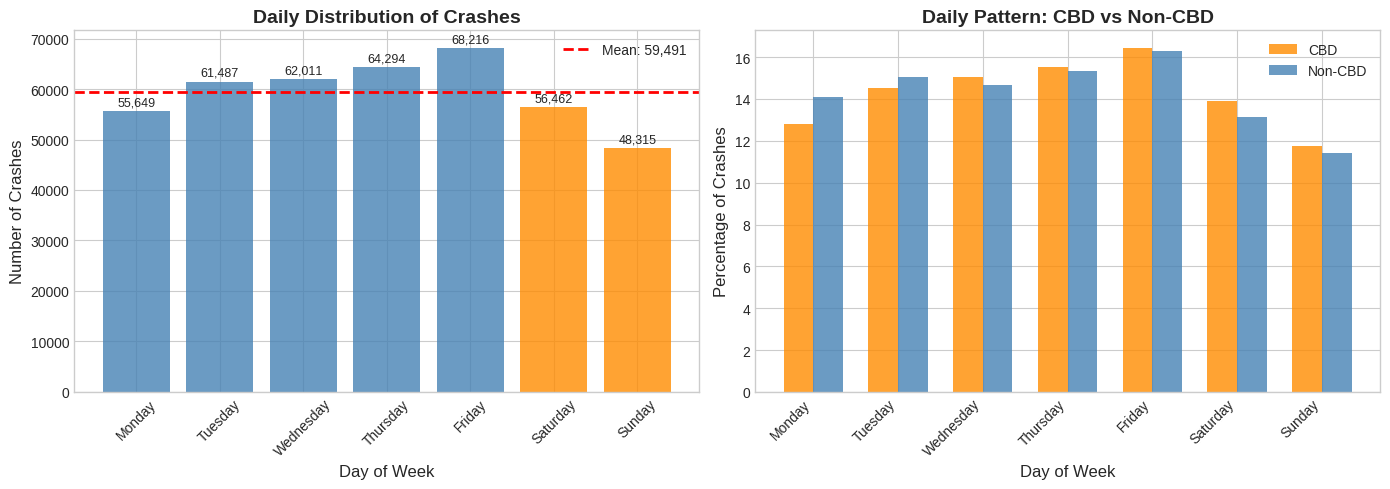


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_daily_demand.png


In [8]:
# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_all = crashes.groupby('day_name').size().reindex(day_order)
daily_cbd = crashes[crashes['in_cbd']].groupby('day_name').size().reindex(day_order)
daily_non_cbd = crashes[~crashes['in_cbd']].groupby('day_name').size().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Absolute counts with weekday/weekend coloring
ax1 = axes[0]
colors = ['steelblue']*5 + ['darkorange']*2  # Weekday vs Weekend
bars = ax1.bar(day_order, daily_all.values, color=colors, alpha=0.8)
ax1.axhline(daily_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {daily_all.mean():,.0f}')
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_ylabel('Number of Crashes', fontsize=12)
ax1.set_title('Daily Distribution of Crashes', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

# Add value labels
for bar, val in zip(bars, daily_all.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# Right: Normalized comparison
ax2 = axes[1]
width = 0.35
x = np.arange(len(day_order))
ax2.bar(x - width/2, daily_cbd.values / daily_cbd.sum() * 100, width, label='CBD', color='darkorange', alpha=0.8)
ax2.bar(x + width/2, daily_non_cbd.values / daily_non_cbd.sum() * 100, width, label='Non-CBD', color='steelblue', alpha=0.8)
ax2.set_xlabel('Day of Week', fontsize=12)
ax2.set_ylabel('Percentage of Crashes', fontsize=12)
ax2.set_title('Daily Pattern: CBD vs Non-CBD', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(day_order, rotation=45, ha='right')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_daily_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_daily_demand.png'}")

In [9]:
# Weekday vs Weekend summary
weekday_avg = daily_all.iloc[:5].mean()
weekend_avg = daily_all.iloc[5:].mean()

print(f"\nWeekday vs Weekend Comparison:")
print(f"  Average weekday crashes: {weekday_avg:,.0f}")
print(f"  Average weekend crashes: {weekend_avg:,.0f}")
print(f"  Ratio (Weekday/Weekend): {weekday_avg/weekend_avg:.2f}")


Weekday vs Weekend Comparison:
  Average weekday crashes: 62,331
  Average weekend crashes: 52,388
  Ratio (Weekday/Weekend): 1.19


####  Key Finding: Day-of-Week Patterns

- **Weekday dominance**: Friday typically shows highest crash counts
- **Weekend reduction**: Saturday and Sunday have notably lower crash frequencies
- **CBD effect**: CBD shows stronger weekday concentration due to business activity
- **Simulation implication**: Consider weekday/weekend differentiation in demand models

### 1.3 Monthly and Seasonal Patterns

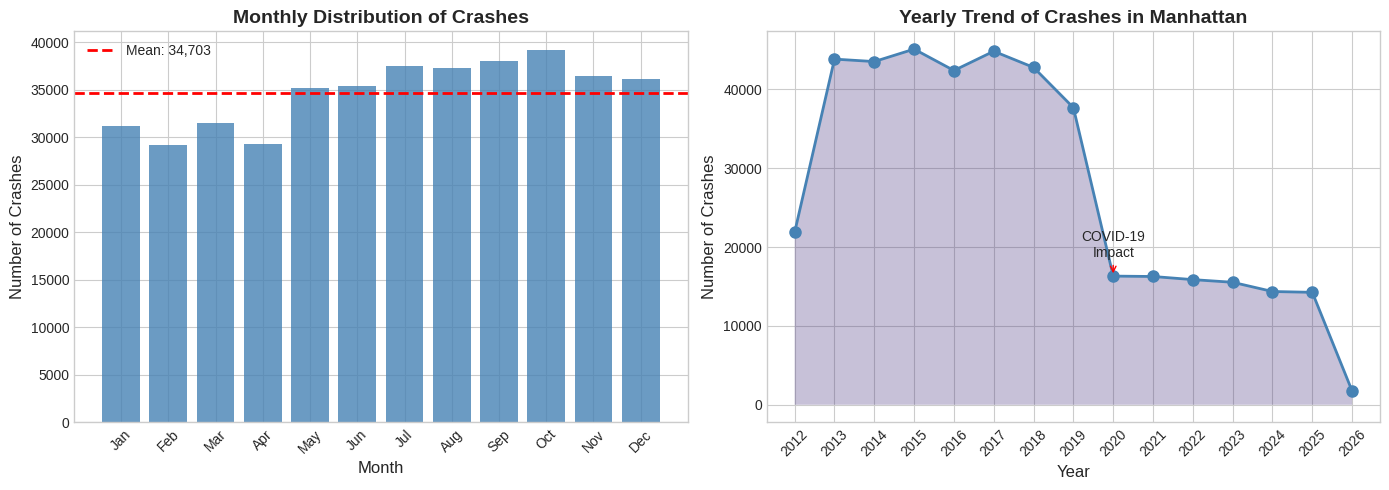


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_temporal_trends.png


In [10]:
# Monthly distribution across all years
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_all = crashes.groupby('month_name').size().reindex(month_order)

# Yearly trends
yearly_counts = crashes.groupby('year').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Monthly pattern
ax1 = axes[0]
bars = ax1.bar(range(12), monthly_all.values, color='steelblue', alpha=0.8)
ax1.axhline(monthly_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {monthly_all.mean():,.0f}')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Number of Crashes', fontsize=12)
ax1.set_title('Monthly Distribution of Crashes', fontsize=14, fontweight='bold')
ax1.set_xticks(range(12))
ax1.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax1.legend()

# Right: Yearly trend
ax2 = axes[1]
ax2.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax2.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Crashes', fontsize=12)
ax2.set_title('Yearly Trend of Crashes in Manhattan', fontsize=14, fontweight='bold')
ax2.set_xticks(yearly_counts.index)
ax2.tick_params(axis='x', rotation=45)

# Annotate COVID dip if visible
if 2020 in yearly_counts.index:
    covid_val = yearly_counts[2020]
    ax2.annotate('COVID-19\nImpact', xy=(2020, covid_val), 
                 xytext=(2020, covid_val*1.15),
                 ha='center', fontsize=10,
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_temporal_trends.png'}")

In [11]:
# Seasonal summary
seasons = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Fall': [9, 10, 11]
}

seasonal_counts = {}
for season, months in seasons.items():
    seasonal_counts[season] = crashes[crashes['month'].isin(months)].shape[0]

print("\nSeasonal Distribution:")
for season, count in seasonal_counts.items():
    pct = count / total_crashes * 100
    print(f"  {season}: {count:,} crashes ({pct:.1f}%)")


Seasonal Distribution:
  Winter: 96,504 crashes (23.2%)
  Spring: 96,024 crashes (23.1%)
  Summer: 110,208 crashes (26.5%)
  Fall: 113,698 crashes (27.3%)


---

## 2. Spatial Analysis

Geographic distribution of crashes informs:
- **Demand hotspots**: Where to position ambulances
- **Precinct-level planning**: Administrative units for resource allocation
- **CBD comparison**: High-density business district patterns

### 2.1 Crash Density Heatmap

In [12]:
# Filter crashes with valid coordinates
crashes_with_coords = crashes.dropna(subset=['LATITUDE', 'LONGITUDE'])
print(f"Crashes with valid coordinates: {len(crashes_with_coords):,} ({len(crashes_with_coords)/len(crashes)*100:.1f}%)")

Crashes with valid coordinates: 416,434 (100.0%)


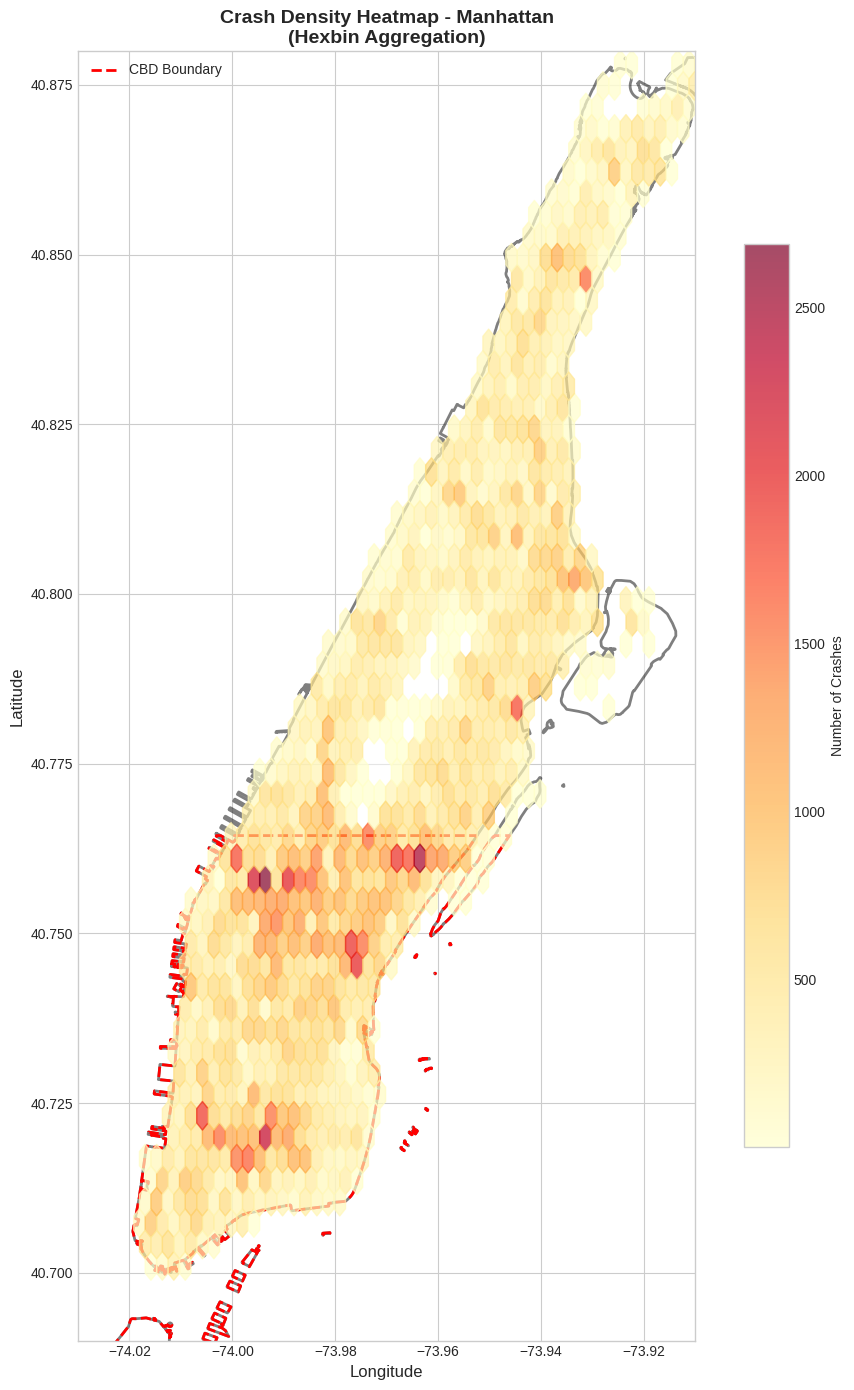


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_crash_heatmap.png


In [13]:
# Create crash heatmap
fig, ax = plt.subplots(figsize=(10, 14))

# Plot Manhattan boundary
manhattan_boundary.plot(ax=ax, color='white', edgecolor='black', linewidth=2, alpha=0.5)

# Plot CBD boundary
cbd_boundary.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--', label='CBD Boundary')

# Create 2D histogram (heatmap)
hb = ax.hexbin(
    crashes_with_coords['LONGITUDE'], 
    crashes_with_coords['LATITUDE'],
    gridsize=50, 
    cmap='YlOrRd', 
    mincnt=1,
    alpha=0.7
)

# Colorbar
cb = plt.colorbar(hb, ax=ax, label='Number of Crashes', shrink=0.7)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Crash Density Heatmap - Manhattan\n(Hexbin Aggregation)', fontsize=14, fontweight='bold')

# Set bounds to Manhattan
ax.set_xlim(-74.03, -73.91)
ax.set_ylim(40.69, 40.88)

# Legend for CBD
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='CBD Boundary')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_crash_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_crash_heatmap.png'}")

####  Key Finding: Crash Density

- **Hotspots**: Midtown and Lower Manhattan show highest crash density
- **CBD concentration**: CBD boundary captures significant portion of high-density areas
- **Simulation implication**: Consider density-weighted ambulance positioning

### 2.2 Crash Density by Precinct

In [14]:
# Convert crashes to GeoDataFrame
crashes_gdf = gpd.GeoDataFrame(
    crashes_with_coords,
    geometry=gpd.points_from_xy(crashes_with_coords['LONGITUDE'], crashes_with_coords['LATITUDE']),
    crs='EPSG:4326'
)

# Spatial join to assign crashes to precincts
crashes_with_precinct = gpd.sjoin(crashes_gdf, precincts[['Precinct', 'geometry']], how='left', predicate='within')

# Count crashes per precinct
precinct_counts = crashes_with_precinct.groupby('Precinct').size().reset_index(name='crash_count')

# Merge with precinct geometries
precincts_with_counts = precincts.merge(precinct_counts, on='Precinct', how='left')
precincts_with_counts['crash_count'] = precincts_with_counts['crash_count'].fillna(0)

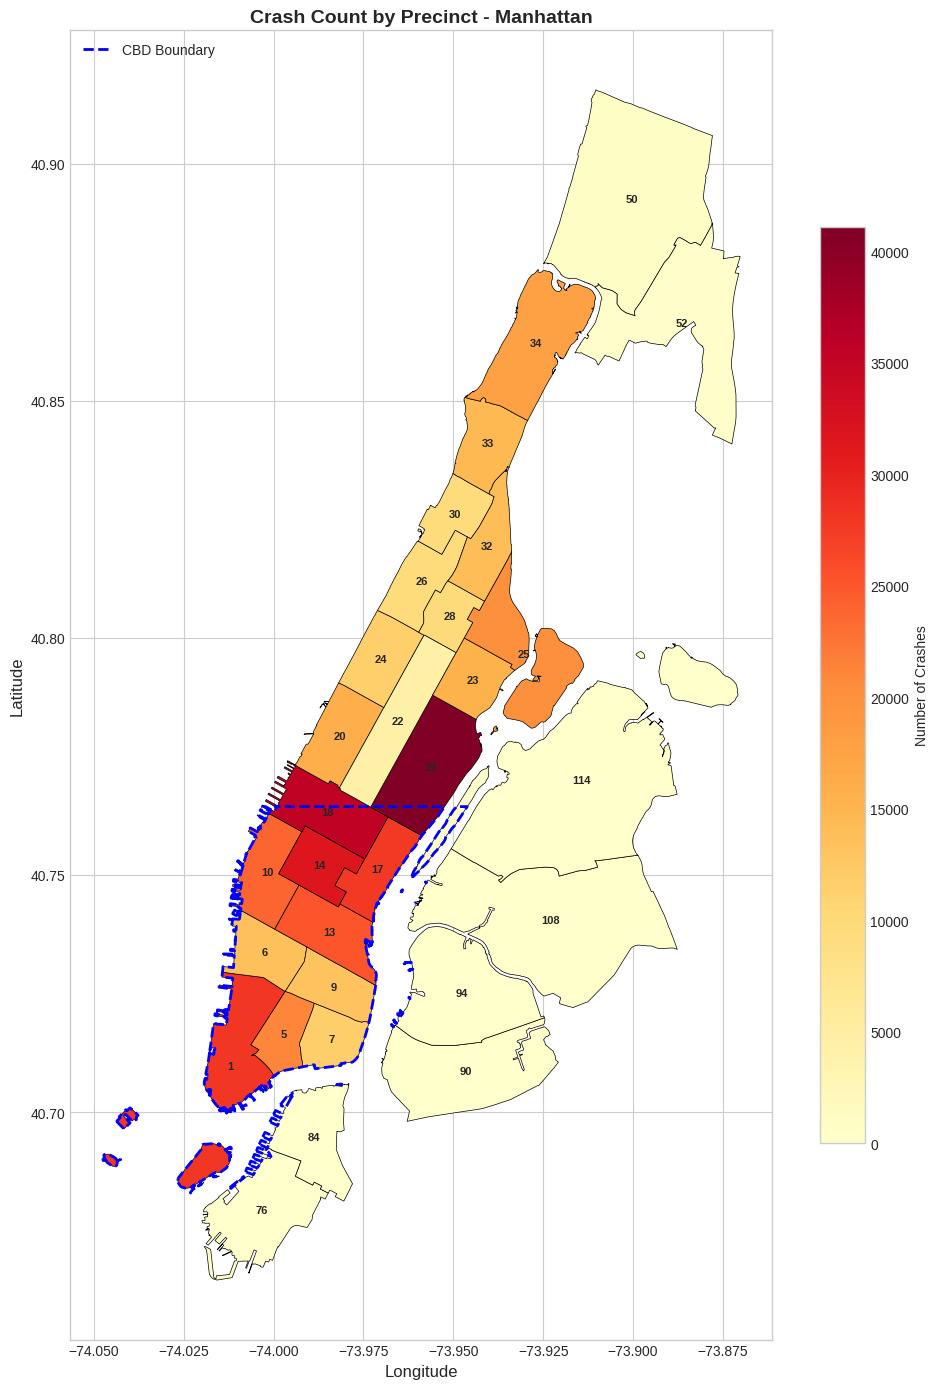


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_precinct_density.png


In [15]:
# Plot precinct-level crash density
fig, ax = plt.subplots(figsize=(10, 14))

# Choropleth by crash count
precincts_with_counts.plot(
    column='crash_count', 
    ax=ax, 
    legend=True, 
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Number of Crashes', 'shrink': 0.7}
)

# Add CBD boundary
cbd_boundary.plot(ax=ax, color='none', edgecolor='blue', linewidth=2, linestyle='--')

# Label precincts
for idx, row in precincts_with_counts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(f"{int(row['Precinct'])}", xy=(centroid.x, centroid.y), 
                ha='center', va='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Crash Count by Precinct - Manhattan', fontsize=14, fontweight='bold')

# Legend
legend_elements = [Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='CBD Boundary')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_precinct_density.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_precinct_density.png'}")

In [16]:
# Top 10 precincts by crash count
print("\nTop 10 Precincts by Crash Count:")
top_precincts = precincts_with_counts[['Precinct', 'crash_count']].nlargest(10, 'crash_count')
for i, row in top_precincts.iterrows():
    print(f"  Precinct {int(row['Precinct'])}: {int(row['crash_count']):,} crashes")


Top 10 Precincts by Crash Count:
  Precinct 19: 41,097 crashes
  Precinct 18: 35,577 crashes
  Precinct 14: 31,551 crashes
  Precinct 1: 27,999 crashes
  Precinct 17: 27,628 crashes
  Precinct 13: 25,101 crashes
  Precinct 10: 23,796 crashes
  Precinct 5: 21,066 crashes
  Precinct 25: 20,129 crashes
  Precinct 34: 17,739 crashes


### 2.3 Firehouse Locations Overlay

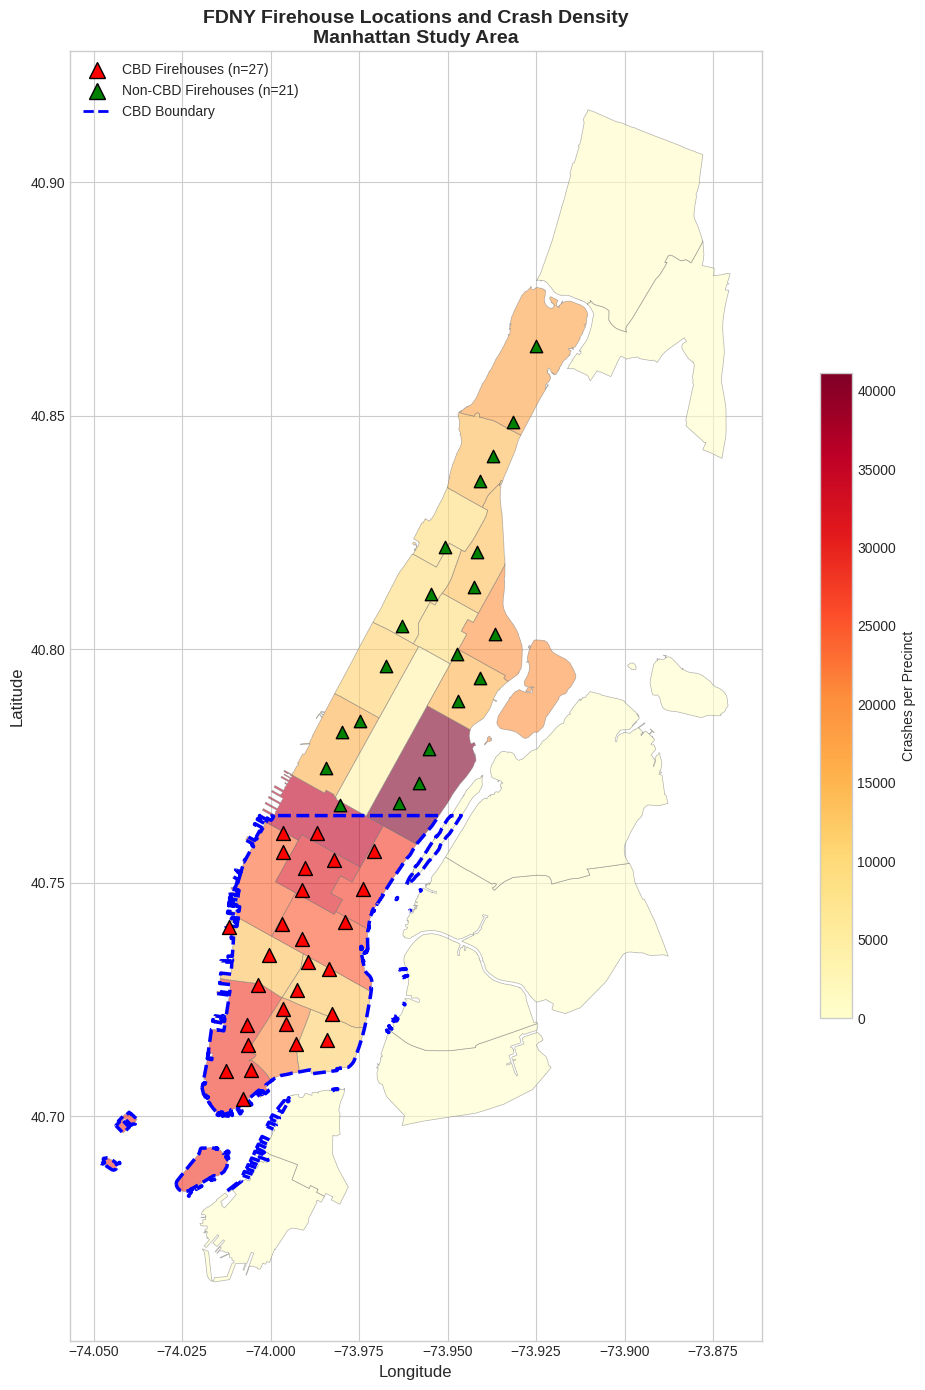


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_firehouses_map.png


In [17]:
# Create firehouse map with crash density background
fig, ax = plt.subplots(figsize=(12, 14))

# Plot precinct crash density as background
precincts_with_counts.plot(
    column='crash_count', 
    ax=ax, 
    cmap='YlOrRd',
    edgecolor='gray',
    linewidth=0.5,
    alpha=0.6,
    legend=True,
    legend_kwds={'label': 'Crashes per Precinct', 'shrink': 0.5}
)

# Plot CBD boundary
cbd_boundary.plot(ax=ax, color='none', edgecolor='blue', linewidth=2.5, linestyle='--')

# Plot all Manhattan firehouses
fh_non_cbd = firehouses_manhattan[firehouses_manhattan['in_cbd'] == False]
fh_cbd = firehouses_manhattan[firehouses_manhattan['in_cbd'] == True]

ax.scatter(fh_non_cbd['Longitude'], fh_non_cbd['Latitude'], 
           c='green', s=80, marker='^', edgecolor='black', linewidth=1, 
           label=f'Non-CBD Firehouses (n={len(fh_non_cbd)})', zorder=5)

ax.scatter(fh_cbd['Longitude'], fh_cbd['Latitude'], 
           c='red', s=100, marker='^', edgecolor='black', linewidth=1, 
           label=f'CBD Firehouses (n={len(fh_cbd)})', zorder=5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('FDNY Firehouse Locations and Crash Density\nManhattan Study Area', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markersize=12, 
           markeredgecolor='black', label=f'CBD Firehouses (n={len(fh_cbd)})'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='green', markersize=12, 
           markeredgecolor='black', label=f'Non-CBD Firehouses (n={len(fh_non_cbd)})'),
    Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='CBD Boundary')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_firehouses_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_firehouses_map.png'}")

####  Key Finding: Firehouse Distribution

- **Good coverage**: Firehouses are well-distributed across Manhattan
- **CBD concentration**: Higher density of firehouses in CBD aligns with higher crash density
- **Simulation implication**: Use all 48 Manhattan firehouses as potential staging locations

### 2.4 CBD vs Non-CBD Comparison

In [18]:
# Calculate CBD vs Non-CBD statistics
cbd_stats = {
    'Total Crashes': [crashes['in_cbd'].sum(), (~crashes['in_cbd']).sum()],
    'Percentage': [crashes['in_cbd'].mean() * 100, (~crashes['in_cbd']).mean() * 100],
    'Firehouses': [len(fh_cbd), len(fh_non_cbd)],
    'Crashes per Firehouse': [
        crashes['in_cbd'].sum() / len(fh_cbd) if len(fh_cbd) > 0 else 0,
        (~crashes['in_cbd']).sum() / len(fh_non_cbd) if len(fh_non_cbd) > 0 else 0
    ]
}

cbd_comparison = pd.DataFrame(cbd_stats, index=['CBD', 'Non-CBD'])
print("\nCBD vs Non-CBD Comparison:")
print(cbd_comparison.to_string())


CBD vs Non-CBD Comparison:
         Total Crashes  Percentage  Firehouses  Crashes per Firehouse
CBD             231786    55.65972          27            8584.666667
Non-CBD         184648    44.34028          21            8792.761905


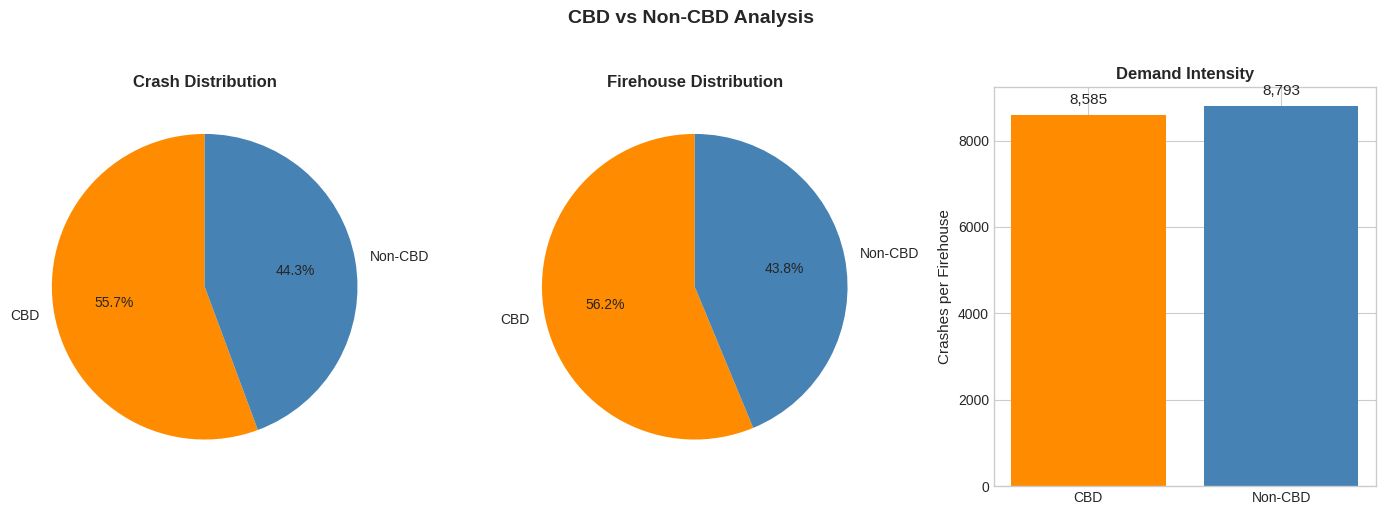


[PASS] Saved: /home/ubuntu/ems-optimization/results/figures/fig_cbd_comparison.png


In [19]:
# Visualize CBD comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Crash distribution
ax1 = axes[0]
sizes = [crashes['in_cbd'].sum(), (~crashes['in_cbd']).sum()]
labels = ['CBD', 'Non-CBD']
colors = ['darkorange', 'steelblue']
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Crash Distribution', fontsize=12, fontweight='bold')

# Firehouse distribution
ax2 = axes[1]
fh_sizes = [len(fh_cbd), len(fh_non_cbd)]
ax2.pie(fh_sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Firehouse Distribution', fontsize=12, fontweight='bold')

# Demand per firehouse
ax3 = axes[2]
demand_per_fh = [sizes[0]/fh_sizes[0], sizes[1]/fh_sizes[1]]
bars = ax3.bar(labels, demand_per_fh, color=colors)
ax3.set_ylabel('Crashes per Firehouse', fontsize=11)
ax3.set_title('Demand Intensity', fontsize=12, fontweight='bold')
for bar, val in zip(bars, demand_per_fh):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{val:,.0f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('CBD vs Non-CBD Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_cbd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[PASS] Saved: {FIGURES_DIR / 'fig_cbd_comparison.png'}")

---

## 3. Summary and Simulation Implications

### Key Findings for EMS Simulation Design

In [20]:
# Generate summary statistics for simulation parameters
print("="*70)
print("SUMMARY: Key Parameters for EMS Simulation")
print("="*70)

print(f"\n TEMPORAL PARAMETERS")
print(f"   Mean daily arrival rate: {crashes_per_day:.1f} crashes/day")
print(f"   Mean hourly arrival rate: {crashes_per_hour:.2f} crashes/hour")
print(f"   Peak hour: {peak_hour}:00 (multiplier: {hourly_all.max()/hourly_all.mean():.2f}x mean)")
print(f"   Weekday/Weekend ratio: {weekday_avg/weekend_avg:.2f}")

print(f"\n SPATIAL PARAMETERS")
print(f"   Total staging locations (firehouses): {len(firehouses_manhattan)}")
print(f"   CBD staging locations: {len(fh_cbd)}")
print(f"   Precincts covered: {len(precincts)}")

print(f"\n CBD DEMAND CHARACTERISTICS")
print(f"   CBD crash proportion: {cbd_proportion:.1f}%")
print(f"   CBD crashes per firehouse: {sizes[0]/fh_sizes[0]:,.0f}")
print(f"   Non-CBD crashes per firehouse: {sizes[1]/fh_sizes[1]:,.0f}")

print(f"\n SIMULATION RECOMMENDATIONS")
print(f"   1. Use non-homogeneous Poisson process with hourly arrival rates")
print(f"   2. Apply weekday/weekend demand multipliers")
print(f"   3. Test policies on both CBD-only and full Manhattan scenarios")
print(f"   4. Consider precinct-level demand weighting for staging optimization")
print("="*70)

SUMMARY: Key Parameters for EMS Simulation

 TEMPORAL PARAMETERS
   Mean daily arrival rate: 83.6 crashes/day
   Mean hourly arrival rate: 3.48 crashes/hour
   Peak hour: 16:00 (multiplier: 1.63x mean)
   Weekday/Weekend ratio: 1.19

 SPATIAL PARAMETERS
   Total staging locations (firehouses): 48
   CBD staging locations: 27
   Precincts covered: 30

 CBD DEMAND CHARACTERISTICS
   CBD crash proportion: 55.7%
   CBD crashes per firehouse: 8,585
   Non-CBD crashes per firehouse: 8,793

 SIMULATION RECOMMENDATIONS
   1. Use non-homogeneous Poisson process with hourly arrival rates
   2. Apply weekday/weekend demand multipliers
   3. Test policies on both CBD-only and full Manhattan scenarios
   4. Consider precinct-level demand weighting for staging optimization


### Figures Generated

The following figures have been saved to `results/figures/`:

1. `fig_hourly_demand.png` - Hourly distribution of crashes (overall and CBD vs Non-CBD)
2. `fig_daily_demand.png` - Day-of-week distribution with CBD comparison
3. `fig_temporal_trends.png` - Monthly and yearly trends
4. `fig_crash_heatmap.png` - Spatial heatmap of crash density
5. `fig_precinct_density.png` - Crash counts by precinct
6. `fig_firehouses_map.png` - Firehouse locations overlaid on crash density
7. `fig_cbd_comparison.png` - CBD vs Non-CBD comparison charts

In [21]:
# List generated figures
import os
figures = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')])
print(f"\nGenerated figures ({len(figures)} files):")
for fig in figures:
    print(f"  [PASS] {fig}")


Generated figures (7 files):
  [PASS] fig_cbd_comparison.png
  [PASS] fig_crash_heatmap.png
  [PASS] fig_daily_demand.png
  [PASS] fig_firehouses_map.png
  [PASS] fig_hourly_demand.png
  [PASS] fig_precinct_density.png
  [PASS] fig_temporal_trends.png


---

## Next Steps

This EDA provides the foundation for:

1. **Demand Modeling (Phase 2)**: Fit time-varying arrival rate functions based on hourly/daily patterns
2. **Network Construction (Phase 3)**: Build travel time matrix between firehouses and demand centroids
3. **Simulation Design (Phase 4)**: Implement discrete-event simulation with realistic demand parameters
4. **Optimization (Phase 5)**: Use spatial density insights for staging location selection

---
*Notebook created: EMS Readiness Optimization Project*